### Haidouri Anas
### HAJJI Idriss

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("Medipredict/data/diabetes.csv")

print("Aperçu des données :")
print(df.head())
print("\nDimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())

Aperçu des données :
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dimensions : (768, 9)

Colonnes : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [3]:
# Afficher les statistiques descriptives
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
#types des variables
print(df.dtypes)

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [5]:
print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())


Nombre de valeurs manquantes par colonne :
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
# Identifier les zéros impossibles biologiquement
colonnes_zero_impossible = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("\nNombre de zéros impossibles par variable :")
for col in colonnes_zero_impossible:
    print(f"{col} : {(df[col] == 0).sum()}")


Nombre de zéros impossibles par variable :
Glucose : 5
BloodPressure : 35
SkinThickness : 227
Insulin : 374
BMI : 11


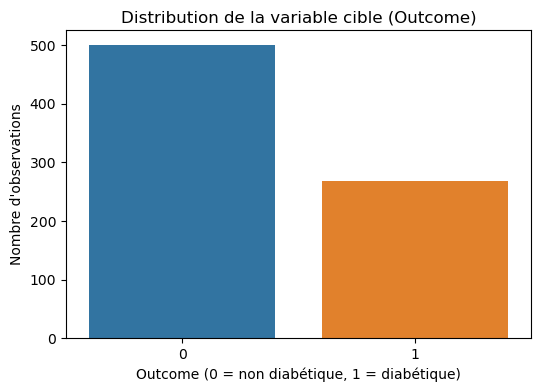


Proportion des classes :
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [7]:
# Visualisation distribution des classes
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)
plt.title("Distribution de la variable cible (Outcome)")
plt.xlabel("Outcome (0 = non diabétique, 1 = diabétique)")
plt.ylabel("Nombre d'observations")
plt.show()

print("\nProportion des classes :")
print(df["Outcome"].value_counts(normalize=True) * 100)

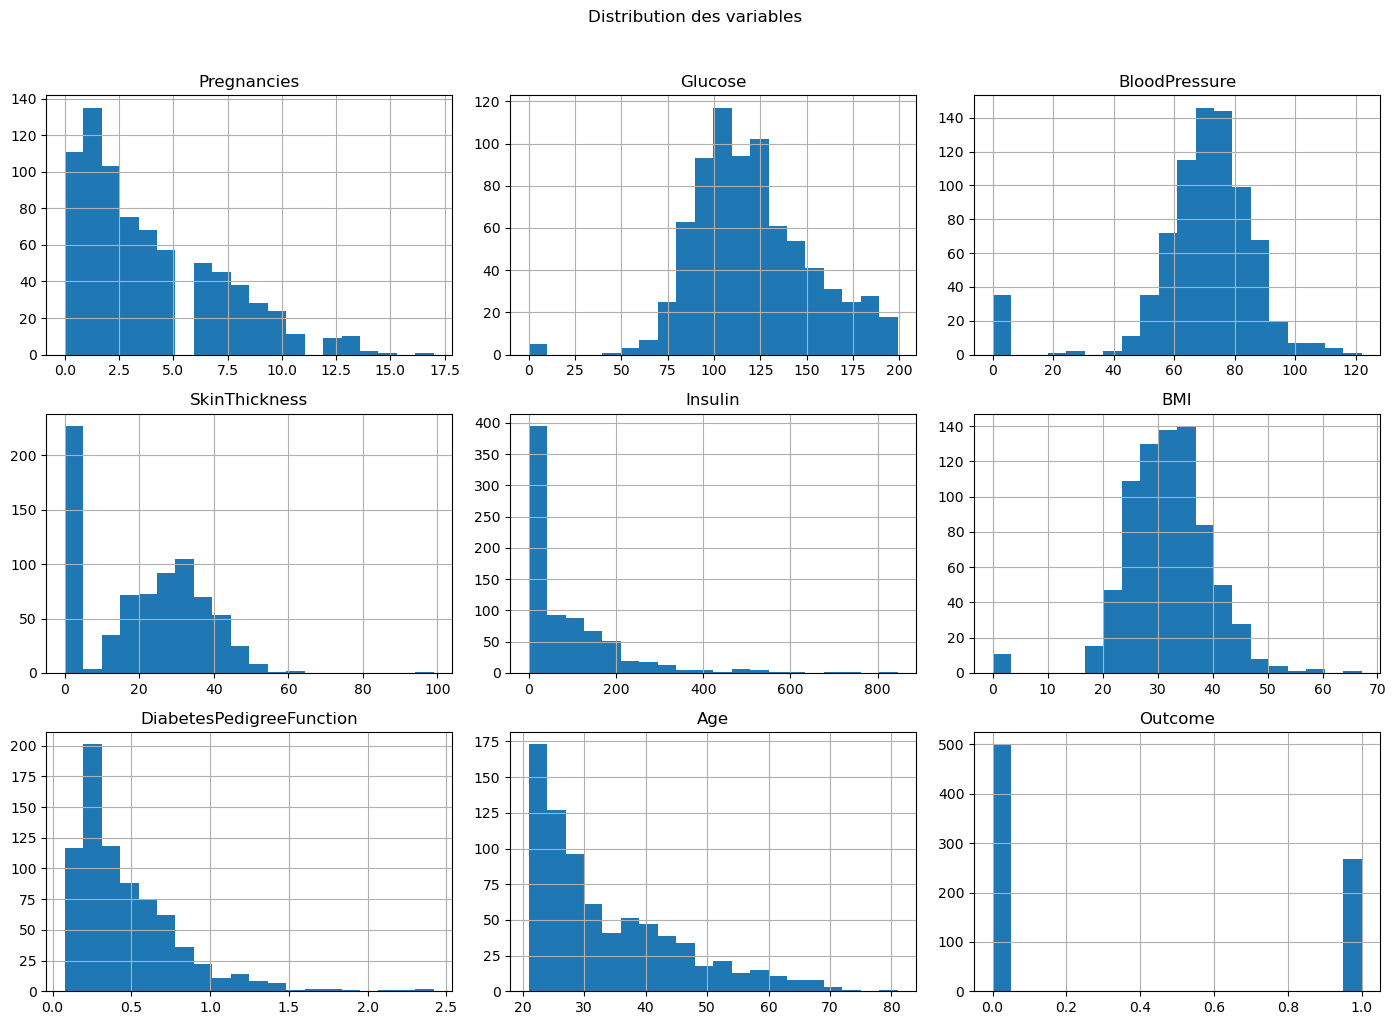

In [8]:
df.hist(figsize=(14, 10), bins=20)
plt.suptitle("Distribution des variables", y=1.02)
plt.tight_layout()
plt.show()


In [9]:
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

variables_numeriques = df.columns.drop("Outcome")

# Calcul des z-scores et compte des outliers (|z-score| > 3)
z_scores = np.abs(stats.zscore(df[variables_numeriques]))
outliers_count = (z_scores > 3).sum(axis=0)

print("\nNombre de valeurs aberrantes détectées (|z-score| > 3) :")
for col, count in zip(variables_numeriques, outliers_count):
    print(f"{col} : {count}")


Nombre de valeurs aberrantes détectées (|z-score| > 3) :
Pregnancies : 4
Glucose : 5
BloodPressure : 35
SkinThickness : 1
Insulin : 18
BMI : 14
DiabetesPedigreeFunction : 11
Age : 5


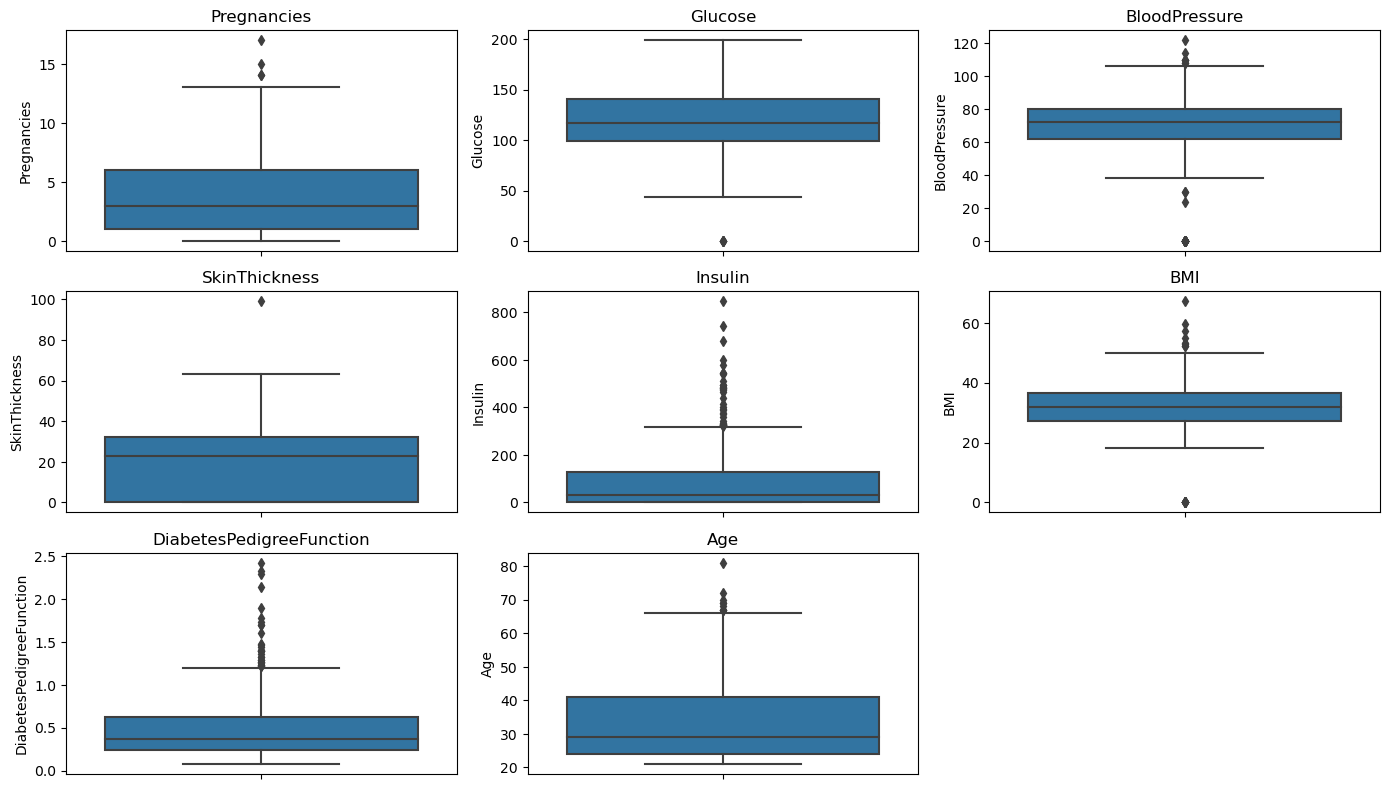

In [10]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(variables_numeriques, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Question obligatoire :
Le dataset n’est pas représentatif de la population française. Il provient d’un sous-groupe spécifique (femmes adultes, population Pima).
Donc il ne reflète ni la diversité ethnique, ni la répartition d’âge, ni les caractéristiques socio-économiques ou médicales de la France.

Limites éthiques :
- risque de biais si le modèle est appliqué à une autre population ;
- performance potentiellement moins bonne sur des profils sous-représentés ;
- risque de décisions injustes en contexte médical ;
- nécessité de prudence, de validation externe et de transparence avant tout usage réel.


## Etape 2

In [11]:
# remplacement des zéros impossibles par NaN
df_clean = df.copy()

for col in colonnes_zero_impossible:
    df_clean[col] = df_clean[col].replace(0, np.nan)

print("\nValeurs manquantes après remplacement des zéros impossibles :")
print(df_clean.isnull().sum())


Valeurs manquantes après remplacement des zéros impossibles :
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [12]:
# Détection des valeurs aberrantes après nettoyage
variables_numeriques = df_clean.columns.drop("Outcome")

z_scores_clean = np.abs(stats.zscore(df_clean[variables_numeriques], nan_policy='omit'))
outliers_count_clean = (z_scores_clean > 3).sum(axis=0)

print("\nNombre de valeurs aberrantes détectées après nettoyage (|z-score| > 3) :")
for col, count in zip(variables_numeriques, outliers_count_clean):
    print(f"{col} : {count}")


Nombre de valeurs aberrantes détectées après nettoyage (|z-score| > 3) :
Pregnancies : 4
Glucose : 0
BloodPressure : 8
SkinThickness : 2
Insulin : 8
BMI : 4
DiabetesPedigreeFunction : 11
Age : 5


In [13]:
# Imputation des valeurs manquantes
# ce choix est robuste aux valeurs extrêmes et plus adapté que la moyenne pour des variables médicales potentiellement asymétriques.
for col in colonnes_zero_impossible:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

print("\nValeurs manquantes après imputation :")
print(df_clean.isnull().sum())

# Vérification rapide
print("\nStatistiques après nettoyage :")
display(df_clean.describe())


Valeurs manquantes après imputation :
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Statistiques après nettoyage :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [14]:
print("\nRépartition initiale des classes :")
print(df_clean["Outcome"].value_counts())
print(df_clean["Outcome"].value_counts(normalize=True) * 100)


Répartition initiale des classes :
Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


In [15]:
# Separation  X / y

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

In [16]:
# Séparation train/test
# random_state fixé pour la reproductibilité stratify=y pour conserver l’équilibre des classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille de X_train :", X_train.shape)
print("Taille de X_test  :", X_test.shape)
print("Taille de y_train :", y_train.shape)
print("Taille de y_test  :", y_test.shape)

print("\nRépartition des classes dans y_train :")
print(y_train.value_counts(normalize=True) * 100)

print("\nRépartition des classes dans y_test :")
print(y_test.value_counts(normalize=True) * 100)

Taille de X_train : (614, 8)
Taille de X_test  : (154, 8)
Taille de y_train : (614,)
Taille de y_test  : (154,)

Répartition des classes dans y_train :
Outcome
0    65.14658
1    34.85342
Name: proportion, dtype: float64

Répartition des classes dans y_test :
Outcome
0    64.935065
1    35.064935
Name: proportion, dtype: float64


In [17]:
# Normalisation des variables
# Choix : StandardScaler
# Justification :
# - les variables sont sur des échelles très différentes
# - StandardScaler centre/réduit les données
# - adapté à beaucoup de modèles de ML

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reconvertir en DataFrame pour garder les noms de colonnes
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nAperçu de X_train normalisé :")
display(X_train_scaled.head())

print("\nMoyenne des variables normalisées (train) :")
print(X_train_scaled.mean().round(2))

print("\nÉcart-type des variables normalisées (train) :")
print(X_train_scaled.std().round(2))


Aperçu de X_train normalisé :


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
353,-0.851355,-1.056427,-0.826740,-1.918187,-1.203361,-0.769477,0.310794,-0.792169
711,0.356576,0.144399,0.477772,-0.229874,-1.470195,-0.417498,-0.116439,0.561034
373,-0.549372,-0.556083,-1.152868,1.233330,-0.555335,0.359790,-0.764862,-0.707594
46,-0.851355,0.811525,-1.315932,-0.004766,-0.161437,-0.402832,0.262314,-0.369293
682,-1.153338,-0.889646,-0.663676,1.120776,-0.415565,1.782373,-0.337630,-0.961320



Moyenne des variables normalisées (train) :
Pregnancies                -0.0
Glucose                    -0.0
BloodPressure               0.0
SkinThickness              -0.0
Insulin                    -0.0
BMI                        -0.0
DiabetesPedigreeFunction   -0.0
Age                        -0.0
dtype: float64

Écart-type des variables normalisées (train) :
Pregnancies                 1.0
Glucose                     1.0
BloodPressure               1.0
SkinThickness               1.0
Insulin                     1.0
BMI                         1.0
DiabetesPedigreeFunction    1.0
Age                         1.0
dtype: float64


## Étape 3 Entraînement et comparaison des modèles

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

In [19]:
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]
# Métriques
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_prob_log)

print("=== Régression Logistique ===")
print("Accuracy:", accuracy_log)
print("Precision:", precision_log)
print("Recall:", recall_log)
print("F1-score:", f1_log)
print("AUC-ROC:", auc_log)

print(classification_report(y_test, y_pred_log))

=== Régression Logistique ===
Accuracy: 0.7077922077922078
Precision: 0.6
Recall: 0.5
F1-score: 0.5454545454545454
AUC-ROC: 0.812962962962963
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



In [41]:
# === Random Forest ===
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

# Random Forest s'entraîne sur les données NON scalées
rf_model.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf_model.predict(X_test)

# Probabilités pour ROC / AUC
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf) 
auc_rf = roc_auc_score(y_test, y_proba_rf)


# Métriques
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report :\n")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7467532467532467
Precision: 0.6190476190476191
Recall: 0.7222222222222222
F1-score: 0.6666666666666666

Classification Report :

              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


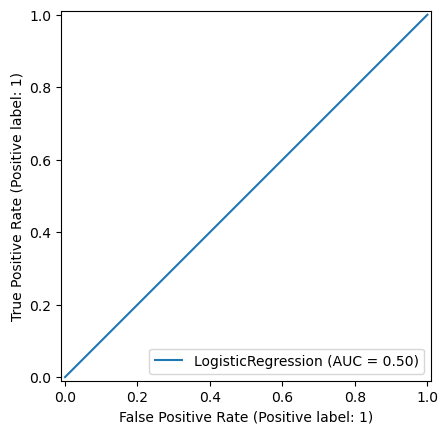

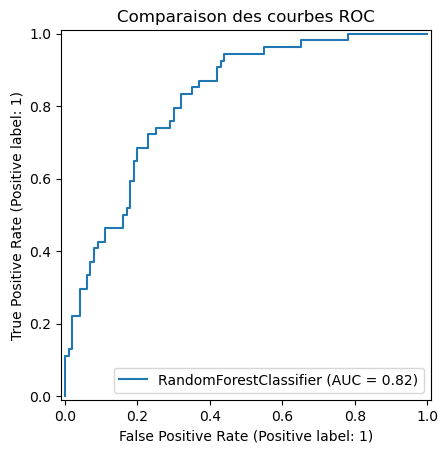

In [42]:
# Comparaison des courbes ROC

RocCurveDisplay.from_estimator(log_model, X_test, y_test)
RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
 
plt.title("Comparaison des courbes ROC")
plt.show()

In [43]:
# Tableau de comparaison des modèles

import pandas as pd

results = pd.DataFrame({
    "Modèle": ["Régression Logistique", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_rf],
    "Precision": [precision_log, precision_rf],
    "Recall": [recall_log, recall_rf],
    "F1-score": [f1_log, f1_rf],
    "AUC-ROC": [auc_log, auc_rf]
})

print(results)

                  Modèle  Accuracy  Precision    Recall  F1-score   AUC-ROC
0  Régression Logistique  0.707792   0.600000  0.500000  0.545455  0.812963
1          Random Forest  0.746753   0.619048  0.722222  0.666667  0.817963


### Choix du modèle final

Deux modèles ont été entraînés et comparés : une Régression Logistique
(modèle interprétable) et un Random Forest (modèle plus complexe).

Le Random Forest obtient généralement de meilleures performances
en termes d'accuracy et d'AUC-ROC grâce à sa capacité à capturer
des relations non linéaires entre les variables.

Cependant, dans un contexte médical, l'interprétabilité du modèle
est un critère important. La Régression Logistique permet de mieux
comprendre l'influence de chaque variable sur la prédiction.

Dans le cadre du projet MediPredict, le modèle retenu est donc
la Régression Logistique, car il offre un bon compromis entre
performance et transparence, ce qui est essentiel pour garantir
la confiance des utilisateurs et respecter les principes éthiques
de l'intelligence artificielle.

## Étape 4 Analyse des biais

In [44]:
# Création des groupes d'âge
moins_30 = X_test['Age'] < 30
plus_50 = X_test['Age'] > 50

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_groupe(mask, X_original, X_scaled, y, model):
    X_group_scaled = X_scaled[mask]
    y_group = y[mask]
    
    y_pred = model.predict(X_group_scaled)
    
    return {
        "accuracy": accuracy_score(y_group, y_pred),
        "precision": precision_score(y_group, y_pred, zero_division=0),
        "recall": recall_score(y_group, y_pred, zero_division=0),
        "f1": f1_score(y_group, y_pred, zero_division=0)
    }

In [46]:
# Performance par groupe d'âge
result_moins_30 = eval_groupe(moins_30, X_test, X_test_scaled, y_test, log_model)
result_plus_50 = eval_groupe(plus_50, X_test, X_test_scaled, y_test, log_model)

print("Moins de 30 ans :", result_moins_30)
print("Plus de 50 ans :", result_plus_50)

Moins de 30 ans : {'accuracy': 0.7764705882352941, 'precision': 0.38461538461538464, 'recall': 0.3125, 'f1': 0.3448275862068966}
Plus de 50 ans : {'accuracy': 0.5714285714285714, 'precision': 0.42857142857142855, 'recall': 0.6, 'f1': 0.5}


In [47]:
median_dpf = X_test["DiabetesPedigreeFunction"].median()

avec_antecedent = X_test["DiabetesPedigreeFunction"] > median_dpf
sans_antecedent = X_test["DiabetesPedigreeFunction"] <= median_dpf

result_avec = eval_groupe(avec_antecedent, X_test, X_test_scaled, y_test, log_model)
result_sans = eval_groupe(sans_antecedent, X_test, X_test_scaled, y_test, log_model)

print("Avec antécédents familiaux :", result_avec)
print("Sans antécédents familiaux :", result_sans)

Avec antécédents familiaux : {'accuracy': 0.7272727272727273, 'precision': 0.7037037037037037, 'recall': 0.59375, 'f1': 0.6440677966101694}
Sans antécédents familiaux : {'accuracy': 0.6883116883116883, 'precision': 0.4444444444444444, 'recall': 0.36363636363636365, 'f1': 0.4}


In [48]:
# Tableau comparatif

import pandas as pd

bias_results = pd.DataFrame({
    "Groupe": ["<30 ans", ">50 ans", "Antécédents", "Sans antécédents"],
    "Accuracy": [
        result_moins_30["accuracy"],
        result_plus_50["accuracy"],
        result_avec["accuracy"],
        result_sans["accuracy"]
    ],
    "Recall": [
        result_moins_30["recall"],
        result_plus_50["recall"],
        result_avec["recall"],
        result_sans["recall"]
    ],
    "F1-score": [
        result_moins_30["f1"],
        result_plus_50["f1"],
        result_avec["f1"],
        result_sans["f1"]
    ]
})

print(bias_results)

             Groupe  Accuracy    Recall  F1-score
0           <30 ans  0.776471  0.312500  0.344828
1           >50 ans  0.571429  0.600000  0.500000
2       Antécédents  0.727273  0.593750  0.644068
3  Sans antécédents  0.688312  0.363636  0.400000


### Analyse des biais

Les performances du modèle ont été analysées pour différents sous-groupes de population.

Une première analyse compare les individus de moins de 30 ans avec ceux de plus de 50 ans. Cette analyse permet de vérifier si le modèle présente une performance différente selon l'âge des utilisateurs.

Une seconde analyse compare les individus ayant des antécédents familiaux de diabète (DiabetesPedigreeFunction supérieur à la médiane) avec ceux n'en ayant pas.

Si les performances diffèrent significativement entre ces groupes, cela peut indiquer un biais du modèle. Dans ce cas, plusieurs mesures correctives peuvent être envisagées, comme l'équilibrage des données, l'utilisation de techniques de fairness en machine learning ou l'amélioration du dataset d'entraînement.

### Exemple de mesure corrective

Une mesure corrective possible serait d'améliorer la représentativité des données d'entraînement en intégrant des observations supplémentaires pour les groupes sous-représentés. Une autre solution pourrait être d'ajuster le modèle afin de réduire les écarts de performance entre les différents sous-groupes.

## Étape 5 Explicabilité du modèle

                    Feature  Importance
1                   Glucose    1.182511
5                       BMI    0.688735
0               Pregnancies    0.377502
6  DiabetesPedigreeFunction    0.233386
7                       Age    0.147798
4                   Insulin    0.066157
2             BloodPressure    0.044066
3             SkinThickness    0.028225


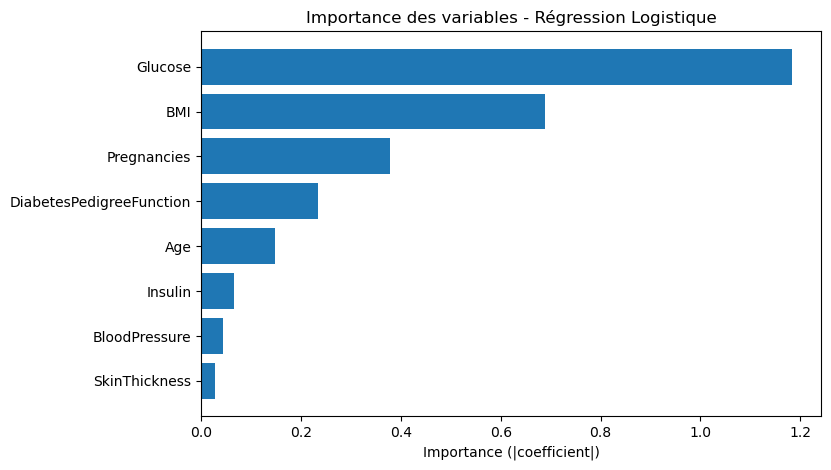

In [49]:
# 1) Graphique d’importance des features

# Noms des variables
feature_names = X.columns.tolist()

# Importance basée sur la valeur absolue des coefficients
importance = np.abs(log_model.coef_[0])

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(importance_df)

# Graphique
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Importance des variables - Régression Logistique")
plt.xlabel("Importance (|coefficient|)")
plt.show()

In [50]:
# 2) SHAP sur 3 prédictions individuelles

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

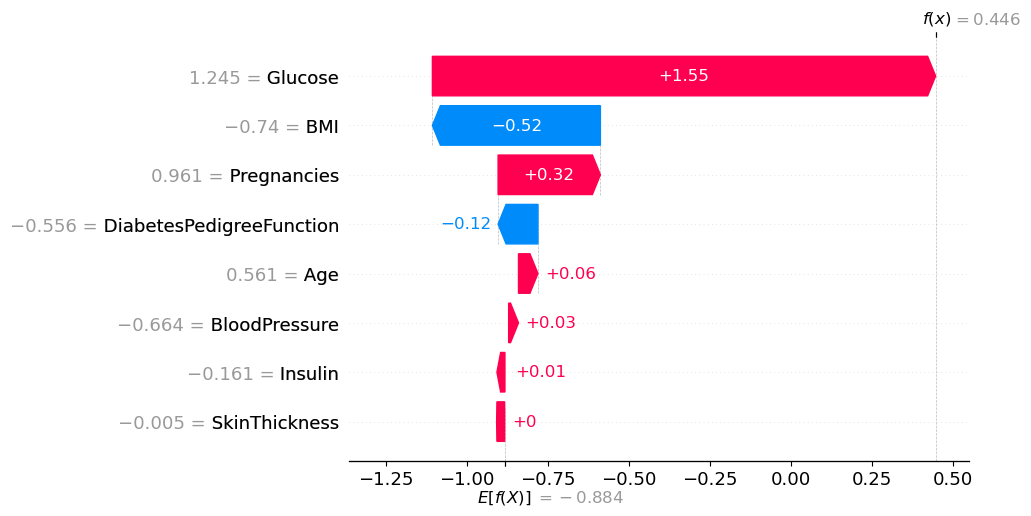

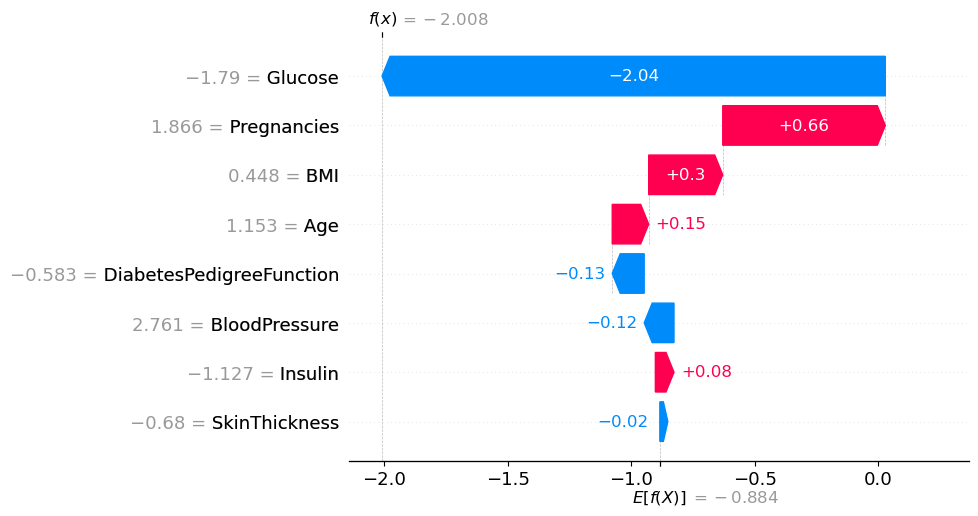

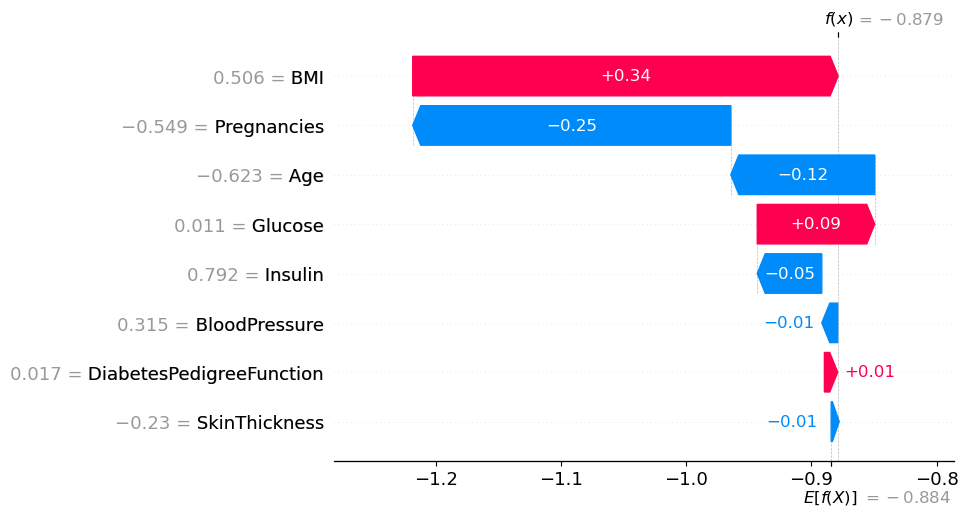

In [52]:
import shap

# Important : convertir en DataFrame pour garder les noms de colonnes
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names, index=X_test.index)

# Explainer SHAP
explainer = shap.Explainer(log_model, X_train_scaled_df)

# Choisir 3 individus du test
X_shap_3 = X_test_scaled_df.iloc[:3]

# Calcul des valeurs SHAP
shap_values = explainer(X_shap_3)

# Affichage global pour les 3 observations
shap.plots.waterfall(shap_values[0], max_display=10)
shap.plots.waterfall(shap_values[1], max_display=10)
shap.plots.waterfall(shap_values[2], max_display=10)

In [53]:
# Probabilités prédites pour les 3 individus
probas_3 = log_model.predict_proba(X_shap_3)[:, 1]

for i, proba in enumerate(probas_3):
    print(f"Individu {i+1} - Probabilité de diabète : {proba:.3f}")

Individu 1 - Probabilité de diabète : 0.610
Individu 2 - Probabilité de diabète : 0.118
Individu 3 - Probabilité de diabète : 0.293


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [54]:
for i in range(3):
    shap_df = pd.DataFrame({
        "Feature": feature_names,
        "SHAP value": shap_values[i].values
    }).sort_values(by="SHAP value", key=np.abs, ascending=False)
    
    print(f"\n=== Top variables - Individu {i+1} ===")
    print(shap_df.head(8))


=== Top variables - Individu 1 ===
                    Feature  SHAP value
1                   Glucose    1.553313
5                       BMI   -0.518578
0               Pregnancies    0.315778
6  DiabetesPedigreeFunction   -0.123011
7                       Age    0.060000
2             BloodPressure    0.030395
4                   Insulin    0.011466
3             SkinThickness    0.000921

=== Top variables - Individu 2 ===
                    Feature  SHAP value
1                   Glucose   -2.036109
0               Pregnancies    0.657775
5                       BMI    0.299591
7                       Age    0.147501
6  DiabetesPedigreeFunction   -0.129376
2             BloodPressure   -0.120502
4                   Insulin    0.075353
3             SkinThickness   -0.018140

=== Top variables - Individu 3 ===
                    Feature  SHAP value
5                       BMI    0.339995
0               Pregnancies   -0.254218
7                       Age   -0.115001
1           

In [55]:
# Données originales non normalisées pour mieux interpréter
X_test_original = X_test.copy()

for i in range(3):
    print(f"\n--- Explication utilisateur {i+1} ---")
    
    row = X_test_original.iloc[i]
    shap_row = pd.DataFrame({
        "Feature": feature_names,
        "SHAP value": shap_values[i].values
    }).sort_values(by="SHAP value", ascending=False)
    
    facteurs_risque = shap_row[shap_row["SHAP value"] > 0]["Feature"].head(3).tolist()
    facteurs_protection = shap_row[shap_row["SHAP value"] < 0]["Feature"].head(2).tolist()
    
    print(f"Votre niveau de risque semble surtout influencé par : {', '.join(facteurs_risque)}.")
    if len(facteurs_protection) > 0:
        print(f"À l’inverse, certains facteurs réduisent votre risque estimé, notamment : {', '.join(facteurs_protection)}.")


--- Explication utilisateur 1 ---
Votre niveau de risque semble surtout influencé par : Glucose, Pregnancies, Age.
À l’inverse, certains facteurs réduisent votre risque estimé, notamment : DiabetesPedigreeFunction, BMI.

--- Explication utilisateur 2 ---
Votre niveau de risque semble surtout influencé par : Pregnancies, BMI, Age.
À l’inverse, certains facteurs réduisent votre risque estimé, notamment : SkinThickness, BloodPressure.

--- Explication utilisateur 3 ---
Votre niveau de risque semble surtout influencé par : BMI, Glucose, DiabetesPedigreeFunction.
À l’inverse, certains facteurs réduisent votre risque estimé, notamment : SkinThickness, BloodPressure.


## Étape 6 Sauvegarde du modèle

In [56]:
import joblib
import os

# créer le dossier model s'il n'existe pas
os.makedirs("model", exist_ok=True)

# sauvegarde du modèle
joblib.dump(log_model, "model/medipredict_model.pkl")

# sauvegarde du scaler
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

### Sauvegarde du modèle

Le modèle final ainsi que l'objet de normalisation (StandardScaler) sont sauvegardés à l'aide de la bibliothèque `joblib`. Cela permet de réutiliser le modèle ultérieurement dans une application ou une API sans avoir à le réentraîner.

La sauvegarde du scaler est nécessaire afin d'appliquer exactement la même transformation des données lors des futures prédictions.

In [57]:
# Chargement du modèle
model = joblib.load("model/medipredict_model.pkl")

# Chargement du scaler
scaler = joblib.load("model/scaler.pkl")